# Inverse Design with PyMieDiff

In this tutorial, we will use the `pymiediff` package to optimize a multi-shell spherical nanoparticle using Gradient Descent via PyTorch. 

### Problem Statement
**Objective:** Maximize the local electric field enhancement $|E|^2$ at the exact center of the core.

**Structure:** A multi-shell nanoparticle with a variable number of layers alternating between Silica ($SiO_2$) and Gold (Au).

**Environment:** Air ($n = 1.0$, $\epsilon_{env} = 1.0$).

**Optimization Parameters:**
- The thickness $d_i$ of each layer.
- The wavelength $\lambda$ of the incident light.

In [1]:
# Installation check
try:
    import pymiediff
    print("pymiediff already installed.")
except ImportError:
    print("Installing pymiediff...")
    !pip install -q https://github.com/UoS-Integrated-Nanophotonics-group/MieDiff/archive/refs/heads/main.zip
    import pymiediff

pymiediff already installed.


# Libraries

In [2]:
# Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pymiediff as pmd

# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Set default dtype to float64 for high precision physics
torch.set_default_dtype(torch.float64)

# Ensure consistent dark style across notebooks
plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor': '#191919', 'axes.facecolor': '#191919', 'savefig.facecolor': '#191919'})

## 1. Define the Forward Pass

We define a function to compute the local electric field intensity at the center of the nanoparticle. It also handles the bookkeeping of the parameters to ensure physical validity (positive thicknesses).

In [3]:
def compute_intensity(d_layers, wl0, num_core_shells, mat_sio2, mat_au, eps_env, r_probe):
    """
    Computes the nearfield intensity at the probe position for a multi-shell nanoparticle.
    """
    # Maintain positive thicknesses and compute cumulative radii
    d_pos = torch.abs(d_layers) + 2.0
    r_layers = torch.cumsum(d_pos, dim=0)
    
    # Get material permittivities at current wavelength
    e_s = mat_sio2.get_epsilon(wl0)
    e_a = mat_au.get_epsilon(wl0)
    
    # Build permittivity stack for the multi-shell structure
    num_layers = 2 * num_core_shells
    eps_list = []
    for i in range(num_core_shells):
        eps_list.extend([e_s, e_a])
        
    eps_l = torch.stack(eps_list, dim=0).reshape(num_layers, 1)
    k0 = (2 * torch.pi / wl0).reshape(1)
    
    # Compute nearfields
    res = pmd.multishell.nearfields(
        k0=k0,
        r_probe=r_probe,
        r_layers=r_layers,
        eps_layers=eps_l,
        eps_env=eps_env,
        n_max=10
    )
    
    # Intensity |E|^2
    intensity = torch.sum(torch.abs(res["E_t"])**2)
    return intensity, d_pos

## 2. The Optimization Loop

Here we set up the parameters, initialize the Adam optimizer, and run the standard PyTorch optimization loop.

In [4]:
def initialize_optimization(num_core_shells, wl_start=650.0, lr=0.1):
    # Setup materials and environment
    mat_sio2 = pmd.materials.MatDatabase("SiO2")
    mat_au = pmd.materials.MatDatabase("Au")
    eps_env = torch.tensor([1.0])
    r_probe = torch.tensor([[0.0, 0.0, 1e-3]], dtype=torch.float64)

    # Initialize thicknesses: 50 nm for the core, then alternating shells
    init_d = []
    for i in range(num_core_shells):
        if i == 0:
            init_d.extend([50.0, 15.0])
        else:
            init_d.extend([20.0, 15.0])
            
    d_layers = torch.nn.Parameter(torch.tensor(init_d, dtype=torch.float64))
    wl0 = torch.nn.Parameter(torch.tensor([wl_start], dtype=torch.float64))

    # Define Optimizer
    optimizer = torch.optim.Adam([d_layers, wl0], lr=lr)

    history = {'loss': [], 'wavelength': [], 'thicknesses': []}
    
    return d_layers, wl0, optimizer, history, mat_sio2, mat_au, eps_env, r_probe

def log_metrics(step, num_iterations, intensity, wl0, d_pos, history):
    history['loss'].append(intensity.item())
    history['wavelength'].append(wl0.item())
    history['thicknesses'].append(d_pos.detach().numpy().copy())
    
    if (step + 1) % max(1, (num_iterations // 10)) == 0:
        print(f"Step {step+1:03d} | Wavelength: {wl0.item():.2f} nm | Intensity: {intensity.item():.4f}")

In [5]:
# Configurable optimization parameters
num_core_shells = 2
num_iterations = 500
wl_start = 650.0
lr = 0.1

d_layers, wl0, optimizer, history, mat_sio2, mat_au, eps_env, r_probe = initialize_optimization(num_core_shells, wl_start, lr)

print(f"Starting optimization for {num_core_shells} core-shell pairs ({2*num_core_shells} layers)...\n")

# Clean Optimization Loop
for step in range(num_iterations):
    optimizer.zero_grad()                   # 1. Clear old gradients
    
    intensity, d_pos = compute_intensity(   # 2. Forward pass (compute local field)
        d_layers, wl0, num_core_shells, 
        mat_sio2, mat_au, eps_env, r_probe
    )
    
    loss = -intensity                       # 3. Compute loss (maximize intensity)
    
    loss.backward(retain_graph=True)        # 4. Compute exact gradients
    optimizer.step()                        # 5. Update weights
    
    log_metrics(step, num_iterations, intensity, wl0, d_pos, history)  # 6. Log metrics

print("\nOptimization complete.")
d_final = d_pos.detach()
wl_final = wl0.detach()
r_final = torch.cumsum(d_final, dim=0)

Starting optimization for 2 core-shell pairs (4 layers)...



Step 050 | Wavelength: 644.55 nm | Intensity: 7.5690


Step 100 | Wavelength: 651.54 nm | Intensity: 36.6892


Step 150 | Wavelength: 661.60 nm | Intensity: 116.9619


Step 200 | Wavelength: 669.81 nm | Intensity: 382.9864


...

Step 300 | Wavelength: 661.92 nm | Intensity: 3580.7611


Step 350 | Wavelength: 659.59 nm | Intensity: 3615.7086


Step 400 | Wavelength: 659.53 nm | Intensity: 3618.4499


Step 450 | Wavelength: 659.61 nm | Intensity: 3618.7764


Step 500 | Wavelength: 659.49 nm | Intensity: 3620.2549

Optimization complete.


## 3. Results Visualization

### 3.1 Gradient Descent History
We plot the objective function $|E|^2$, the optimized wavelength $\lambda$, and the evolution of the geometrical parameters (layer thicknesses) during optimization.

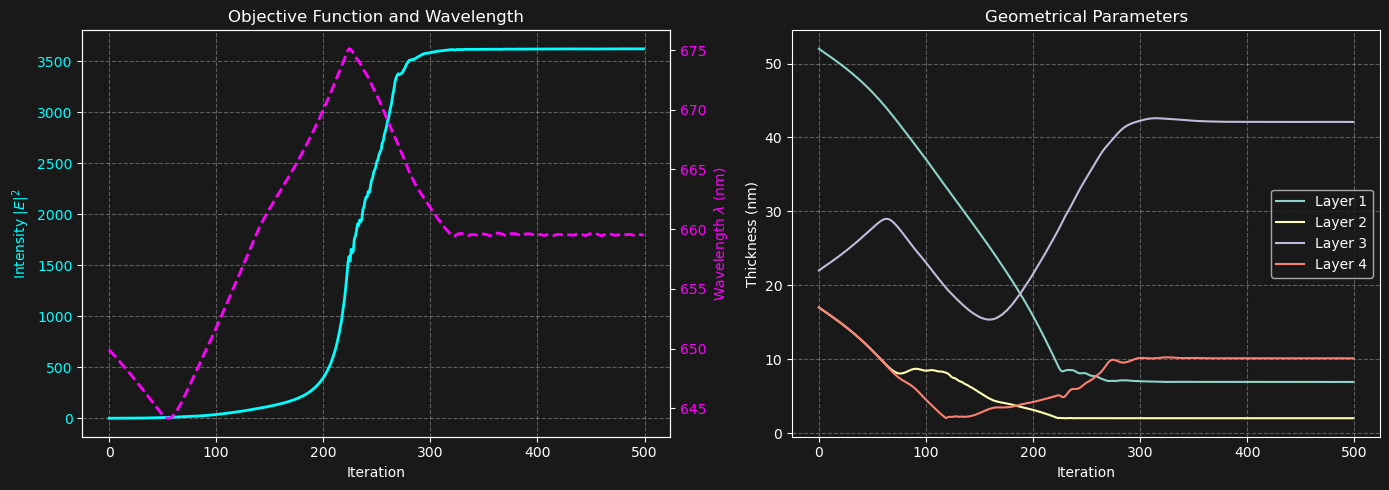

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# panel 1: objective function and wavelength
ax1 = axes[0]
ax1.plot(history['loss'], color='cyan', linewidth=2, label='Intensity')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Intensity $|E|^2$', color='cyan')
ax1.tick_params(axis='y', labelcolor='cyan')
ax1.set_title('Objective Function and Wavelength')
ax1.grid(True, linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(history['wavelength'], color='magenta', linewidth=2, linestyle='--', label='Wavelength')
ax2.set_ylabel(r'Wavelength $\lambda$ (nm)', color='magenta')
ax2.tick_params(axis='y', labelcolor='magenta')

# panel 2: geometrical parameters
thicknesses_history = np.array(history['thicknesses'])
for i in range(thicknesses_history.shape[1]):
    axes[1].plot(thicknesses_history[:, i], label=f'Layer {i+1}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Thickness (nm)')
axes[1].set_title('Geometrical Parameters')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Spectral Analysis
We plot the scattering, absorption, and extinction cross-sections for the final optimized structure to understand its optical properties over a broad wavelength range.

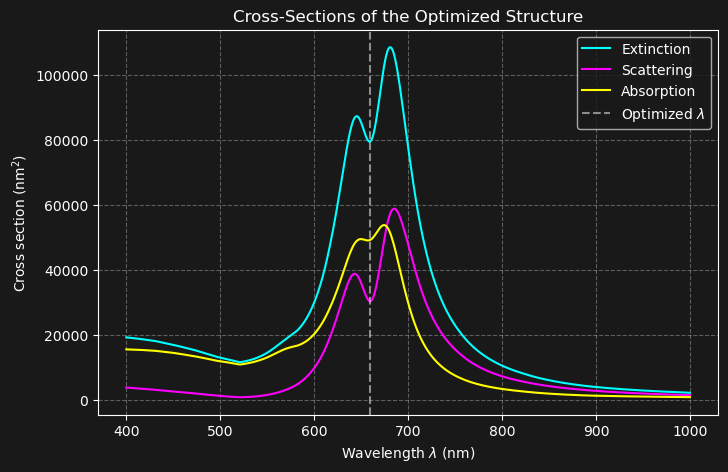

In [7]:
mat_sio2 = pmd.materials.MatDatabase("SiO2")
mat_au = pmd.materials.MatDatabase("Au")

wls = torch.linspace(400, 1000, 500)
ks = 2 * torch.pi / wls
eps_s_r = mat_sio2.get_epsilon(wls)
eps_a_r = mat_au.get_epsilon(wls)

eps_list = []
for i in range(num_core_shells):
    eps_list.extend([eps_s_r, eps_a_r])
eps_l_r = torch.stack(eps_list, dim=0)

cs = pmd.multishell.cross_sections(
    k0=ks,
    r_layers=r_final,
    eps_layers=eps_l_r,
    eps_env=torch.tensor([1.0]),
    n_max=15
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(wls.numpy(), cs["cs_ext"].squeeze().numpy(), label='Extinction', color='cyan')
ax.plot(wls.numpy(), cs["cs_sca"].squeeze().numpy(), label='Scattering', color='magenta')
ax.plot(wls.numpy(), cs["cs_abs"].squeeze().numpy(), label='Absorption', color='yellow')
ax.axvline(wl_final.item(), color='white', linestyle='--', alpha=0.5, label=r'Optimized $\lambda$')
ax.legend()
ax.set_xlabel(r'Wavelength $\lambda$ (nm)')
ax.set_ylabel('Cross section (nm$^2$)')
ax.set_title('Cross-Sections of the Optimized Structure')
ax.grid(True, linestyle='--', alpha=0.3)
plt.show()

### 3.3 Local Electric Field Distribution
Finally, we visualize the highly enhanced local electric field $|E|^2$ around and inside the nanoparticle.

#### 3.3.1 Map computation

In [8]:
# Define overall and zoomed view parameters
L_overall = r_final[-1].item() + 50.0
r_cs1 = r_final[1].item()
L_zoom = r_cs1 + 20.0
res = 500

# Create grids for field mapping
_x_o = torch.linspace(-L_overall, L_overall, res)
_z_o = torch.linspace(-L_overall, L_overall, res)
grid_x_o, grid_z_o = torch.meshgrid(_x_o, _z_o, indexing='ij')
probes_overall = torch.stack([grid_x_o, torch.zeros_like(grid_x_o), grid_z_o], dim=-1).view(-1, 3)

_x_z = torch.linspace(-L_zoom, L_zoom, res)
_z_z = torch.linspace(-L_zoom, L_zoom, res)
grid_x_z, grid_z_z = torch.meshgrid(_x_z, _z_z, indexing='ij')
probes_zoom = torch.stack([grid_x_z, torch.zeros_like(grid_x_z), grid_z_z], dim=-1).view(-1, 3)

# Compute field maps at optimized wavelength
eps_f = torch.stack([mat_sio2.get_epsilon(wl_final), mat_au.get_epsilon(wl_final)] * num_core_shells, dim=0).reshape(-1, 1)
k0_final = torch.tensor([2 * torch.pi / wl_final.item()])

nf_o = pmd.multishell.nearfields(k0=k0_final, r_probe=probes_overall, r_layers=r_final, eps_layers=eps_f, eps_env=torch.tensor([1.0]), n_max=20)
intensity_o = torch.sum(torch.abs(nf_o["E_t"])**2, dim=-1).view(res, res)

nf_z = pmd.multishell.nearfields(k0=k0_final, r_probe=probes_zoom, r_layers=r_final, eps_layers=eps_f, eps_env=torch.tensor([1.0]), n_max=20)
intensity_z = torch.sum(torch.abs(nf_z["E_t"])**2, dim=-1).view(res, res)


#### 3.3.2 Map plot

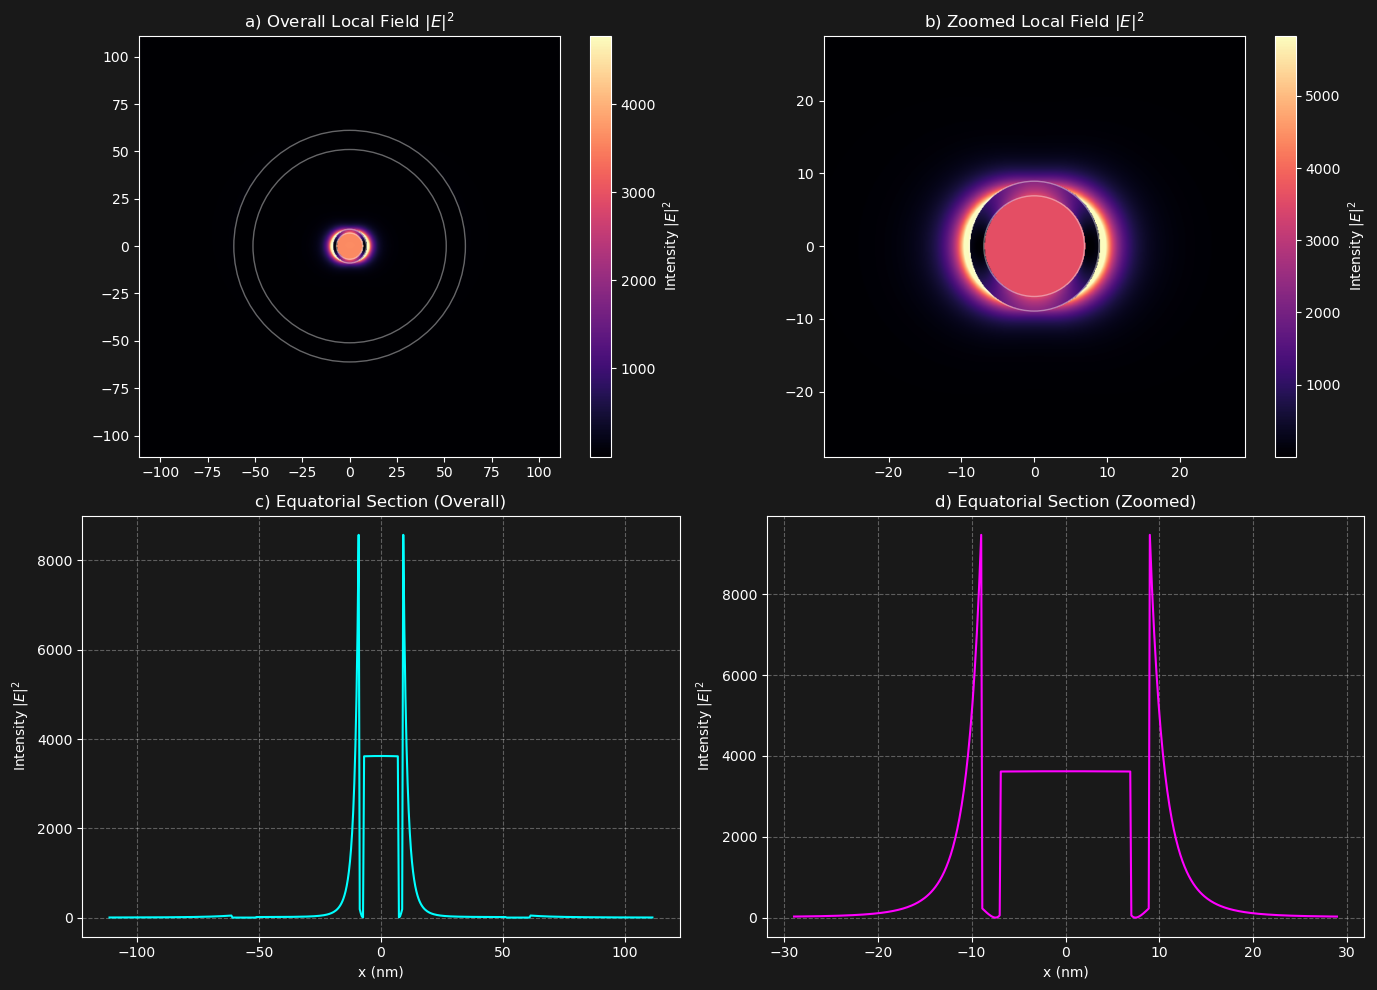

In [9]:
# Visualization: 4-panel plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
mid_idx = res // 2

# a) Overall local field map
im_a = axes[0, 0].imshow(intensity_o.numpy().T, extent=[-L_overall, L_overall, -L_overall, L_overall], 
                         origin='lower', cmap='magma', interpolation='bilinear', vmax=np.percentile(intensity_o.numpy(), 99.95))
axes[0, 0].set_title('a) Overall Local Field $|E|^2$')
fig.colorbar(im_a, ax=axes[0, 0], label='Intensity $|E|^2$')
for r in r_final.numpy()[::-1]:
    axes[0, 0].add_patch(Circle((0,0), r, ec='w', fc='none', alpha=0.4))

# b) Zoomed local field map
im_b = axes[0, 1].imshow(intensity_z.numpy().T, extent=[-L_zoom, L_zoom, -L_zoom, L_zoom], 
                         origin='lower', cmap='magma', interpolation='bilinear', vmax=np.percentile(intensity_z.numpy(), 99.5))
axes[0, 1].set_title('b) Zoomed Local Field $|E|^2$')
fig.colorbar(im_b, ax=axes[0, 1], label='Intensity $|E|^2$')
for r in r_final.numpy()[::-1]:
    if r < L_zoom * 1.5:
        axes[0, 1].add_patch(Circle((0,0), r, ec='w', fc='none', alpha=0.4))

# c) Equatorial section of all local field
axes[1, 0].plot(_x_o.numpy(), intensity_o[:, mid_idx].numpy(), color='cyan')
axes[1, 0].set_title('c) Equatorial Section (Overall)')
axes[1, 0].set_xlabel('x (nm)')
axes[1, 0].set_ylabel('Intensity $|E|^2$')
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

# d) Equatorial section of zoomed local field
axes[1, 1].plot(_x_z.numpy(), intensity_z[:, mid_idx].numpy(), color='magenta')
axes[1, 1].set_title('d) Equatorial Section (Zoomed)')
axes[1, 1].set_xlabel('x (nm)')
axes[1, 1].set_ylabel('Intensity $|E|^2$')
axes[1, 1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()